# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**: [Bank Transactions Dataset for Fraud Detection](https://www.kaggle.com/datasets/thuandao/bank-transactions-dataset-for-fraud-detection)  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import os
import zipfile
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from google.colab import userdata
from sklearn.preprocessing import LabelEncoder, StandardScaler

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
# Kaggle API Configuration
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

In [3]:
!kaggle datasets download -d thuandao/bank-transactions-dataset-for-fraud-detection

Dataset URL: https://www.kaggle.com/datasets/thuandao/bank-transactions-dataset-for-fraud-detection
License(s): apache-2.0
100% 1.53M/1.53M [00:00<00:00, 149MB/s]



In [4]:
zip_path = "/content/bank-transactions-dataset-for-fraud-detection.zip"
extract_path = "/content/"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [5]:
# Data Loading
df = pd.read_csv("/content/bank_transactions_data_2_augmented_clean_2.csv")
df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
0,TX000001,AC00128,14.09,4/11/2023 16:29,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21
1,TX000002,AC00455,376.24,6/27/2023 16:44,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91
2,TX000003,AC00019,126.29,7/10/2023 18:16,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35
3,TX000004,AC00070,184.50,5/5/2023 16:32,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06
4,TX000005,AC00411,13.45,10/16/2023 17:51,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40


In [6]:
# Data Summary
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   TransactionID        50000 non-null  object 
 1   AccountID            50000 non-null  object 
 2   TransactionAmount    50000 non-null  float64
 3   TransactionDate      50000 non-null  object 
 4   TransactionType      50000 non-null  object 
 5   Location             50000 non-null  object 
 6   DeviceID             50000 non-null  object 
 7   IP Address           50000 non-null  object 
 8   MerchantID           50000 non-null  object 
 9   Channel              50000 non-null  object 
 10  CustomerAge          50000 non-null  int64  
 11  CustomerOccupation   50000 non-null  object 
 12  TransactionDuration  50000 non-null  int64  
 13  LoginAttempts        50000 non-null  int64  
 14  AccountBalance       50000 non-null  float64
dtypes: float64(2), int64(3), object(10)


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [7]:
# Descriptive Statistic
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
TransactionID,50000,50000,TX049984,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AccountID,50000,495,AC00363,249,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TransactionAmount,50000.0,NaN,NaN,NaN,297.872214,292.818888,0.24,82.8975,209.355,409.625,2060.59
TransactionDate,50000,6373,6/12/2021,35,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TransactionType,50000,2,Debit,38747,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Location,50000,43,Fort Worth,1396,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DeviceID,50000,681,D000548,196,NaN,NaN,NaN,NaN,NaN,NaN,NaN
IP Address,50000,592,200.136.146.93,261,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MerchantID,50000,100,M026,940,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Channel,50000,3,Branch,17278,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
# Missing Value
df.isnull().sum()

,0
TransactionID,0
AccountID,0
TransactionAmount,0
TransactionDate,0
TransactionType,0
Location,0
DeviceID,0
IP Address,0
MerchantID,0
Channel,0


In [9]:
# Data Duplicate
df.duplicated().sum()

np.int64(0)

In [10]:
# Separate Numerical and Categorical Data
def separate_data_types(df):
    numerical = [col for col in df.columns if df[col].dtype != 'object']
    categorical = [col for col in df.columns if df[col].dtype == 'object']
    return numerical, categorical

numerical, categorical = separate_data_types(df)

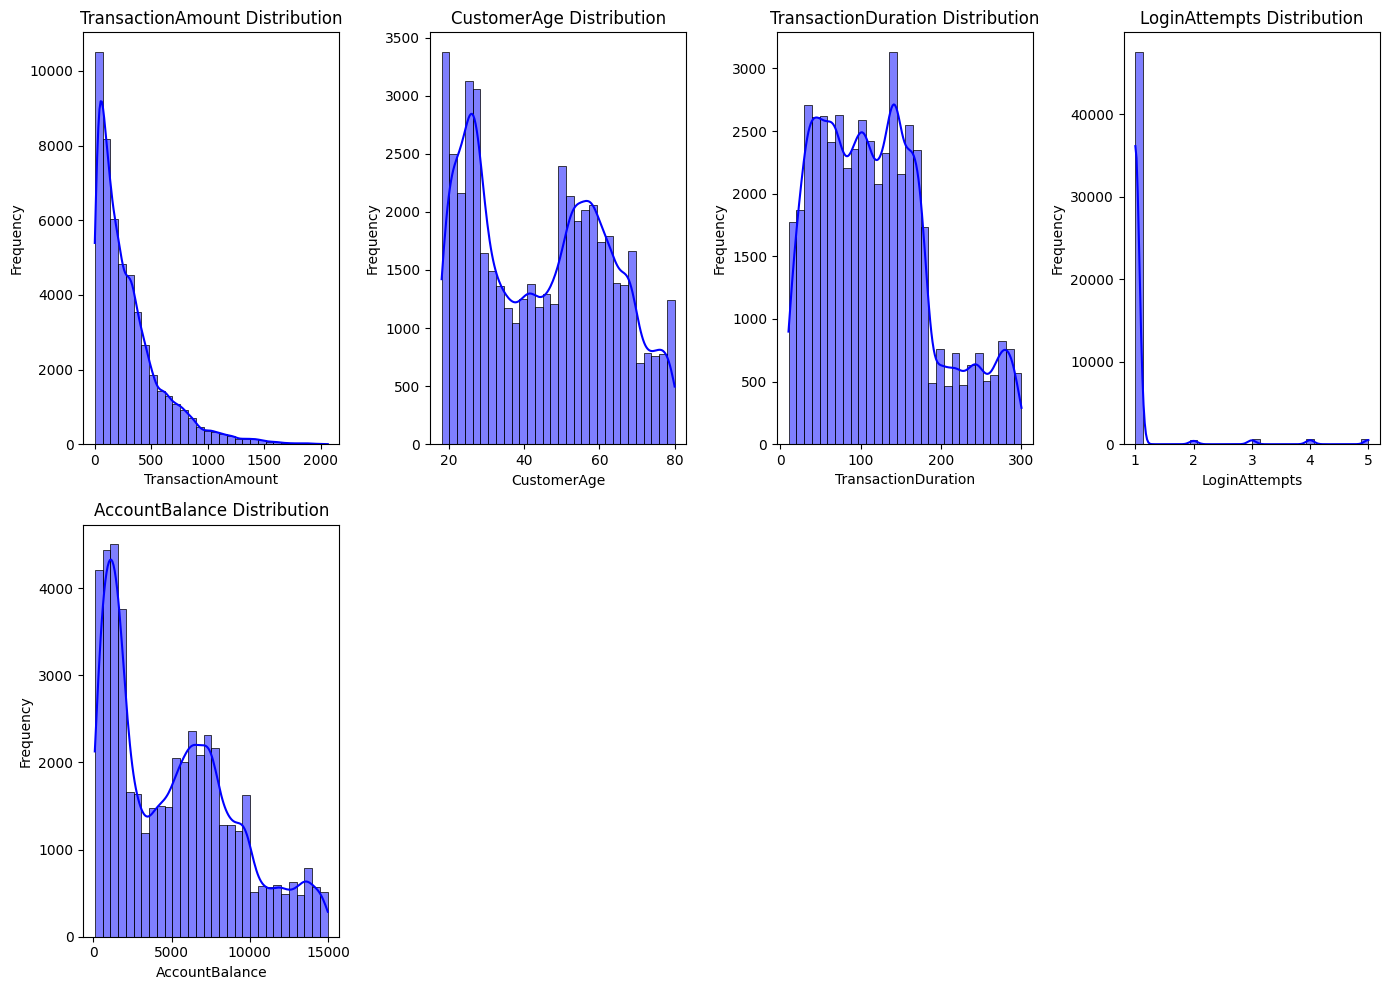

In [11]:
# Numeric Feature Distribution
plt.figure(figsize=(14, 10))
for i, column in enumerate(numerical, 1):
    plt.subplot((len(numerical) // 4) + 1, 4, i)
    sns.histplot(df[column], bins=30, kde=True, color='blue')
    plt.title(f'{column} Distribution')
    plt.xlabel(column)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

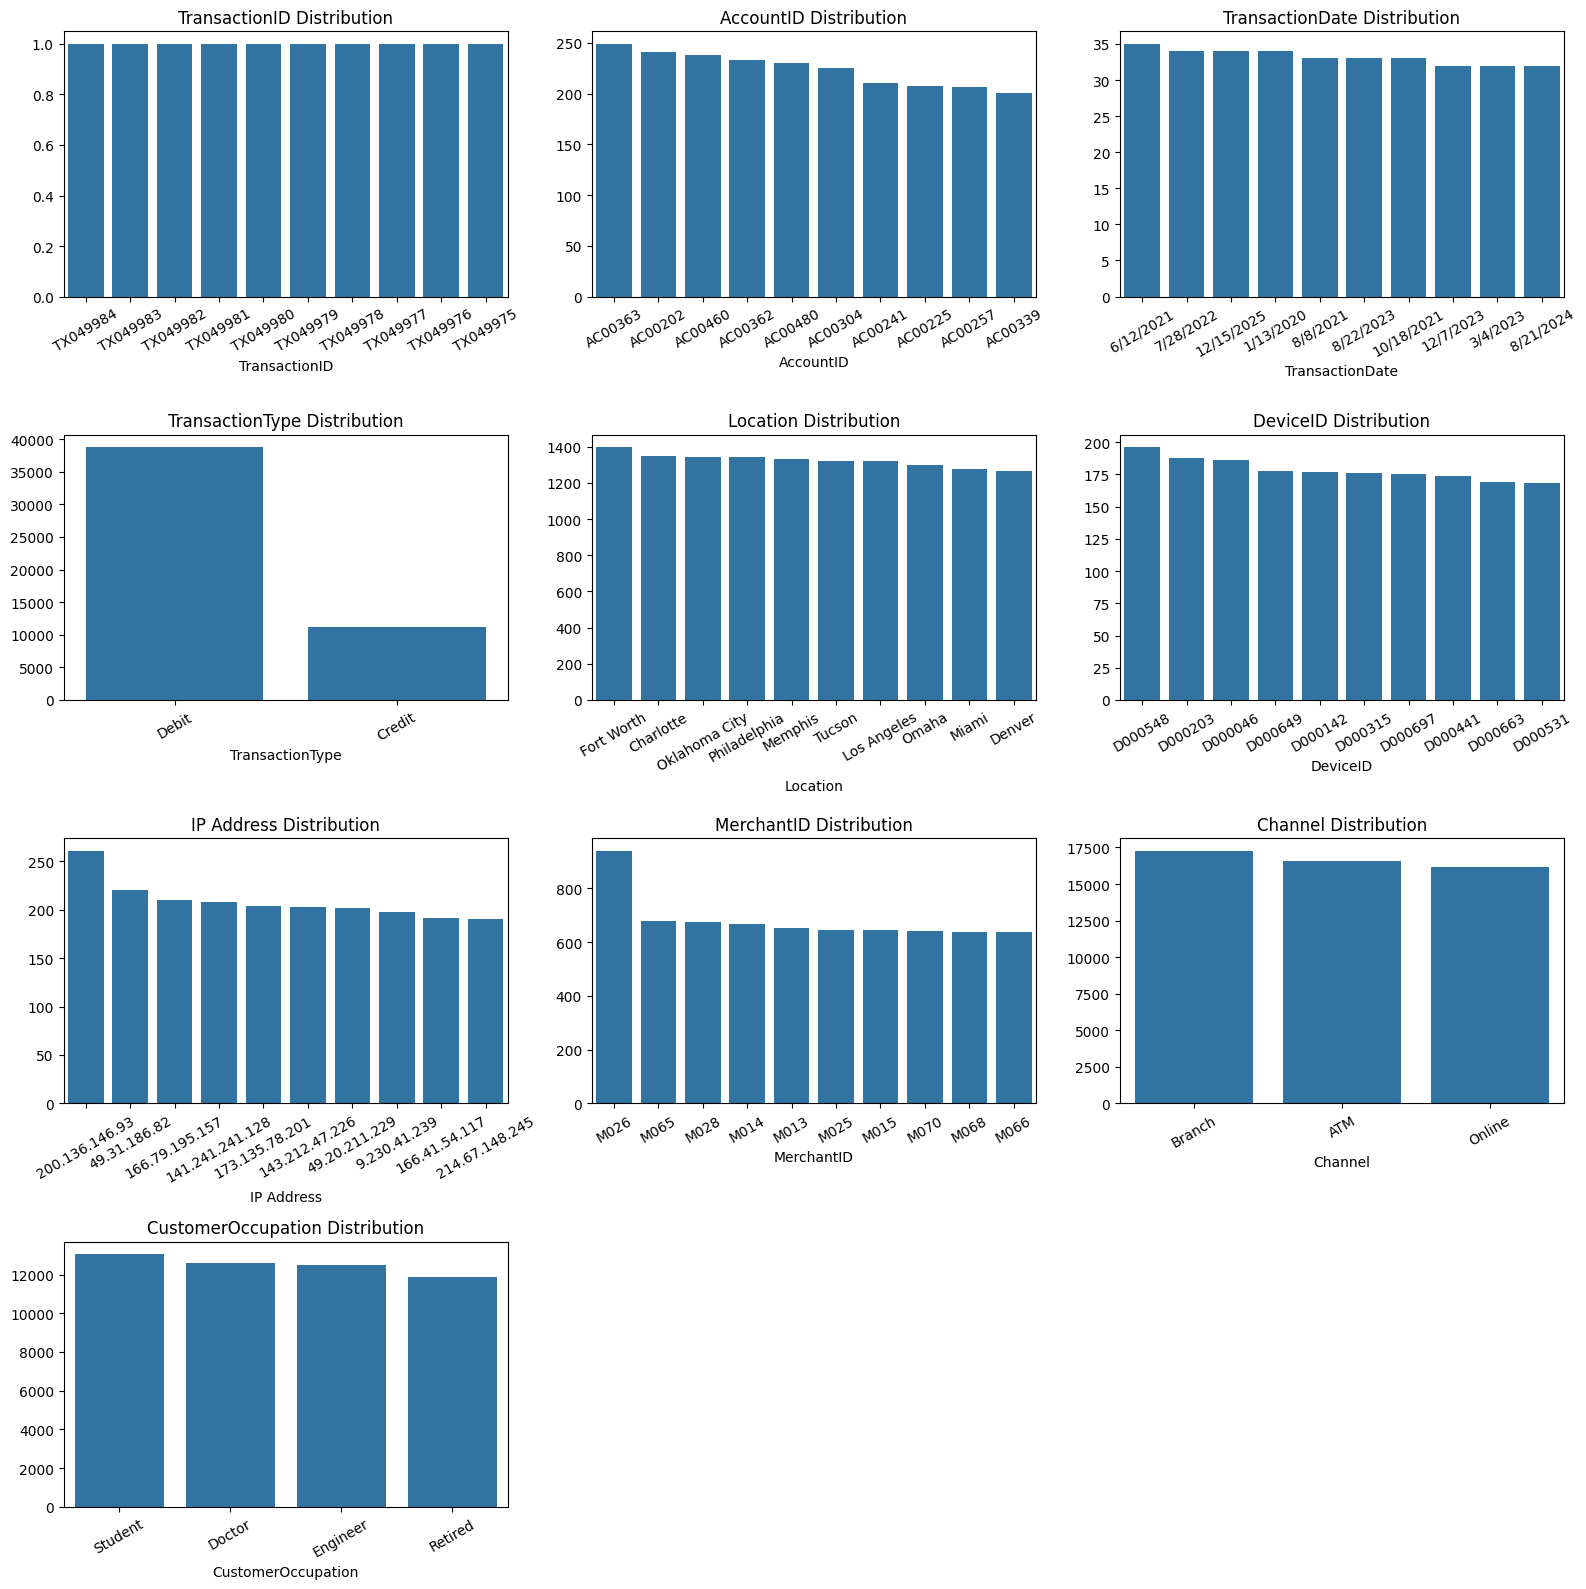

In [12]:
# Categorical Feature Distribution
plt.figure(figsize=(16, 16))
n_cols = 3
n_rows = (len(categorical) // n_cols) + 1

for i, column in enumerate(categorical, 1):
    plt.subplot(n_rows, n_cols, i)
    top_categories = df[column].value_counts().nlargest(10)
    sns.barplot(
        x=top_categories.index,
        y=top_categories.values
    )
    plt.title(f'{column} Distribution')
    plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

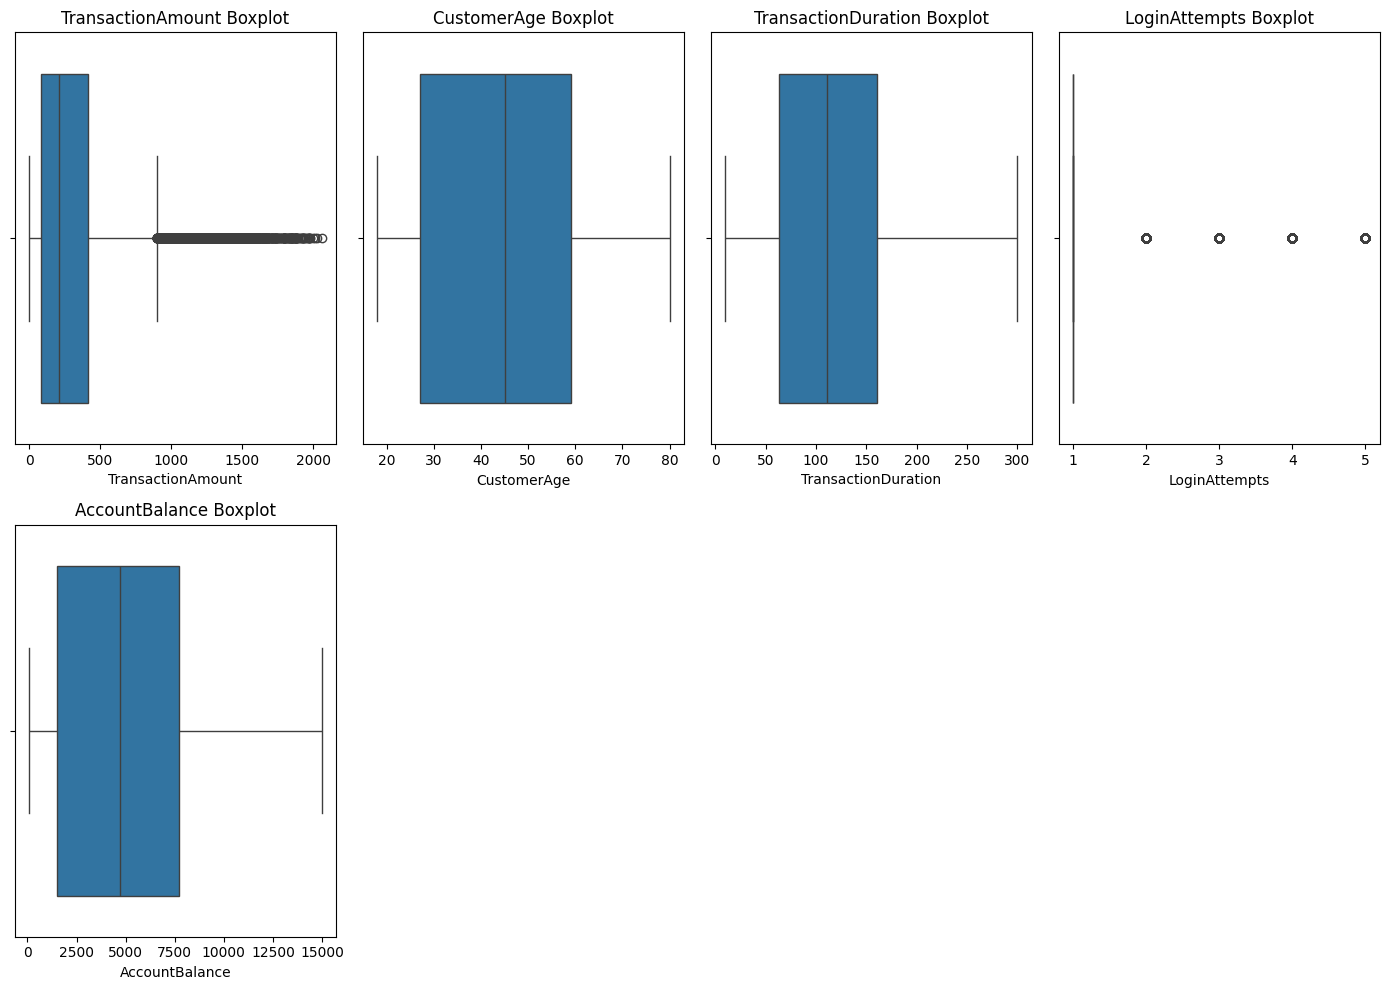

In [13]:
# Outliers
plt.figure(figsize=(14, 10))
for i, column in enumerate(numerical, 1):
    plt.subplot((len(numerical) // 4) + 1, 4, i)
    sns.boxplot(x=df[column])
    plt.title(f'{column} Boxplot')

plt.tight_layout()
plt.show()

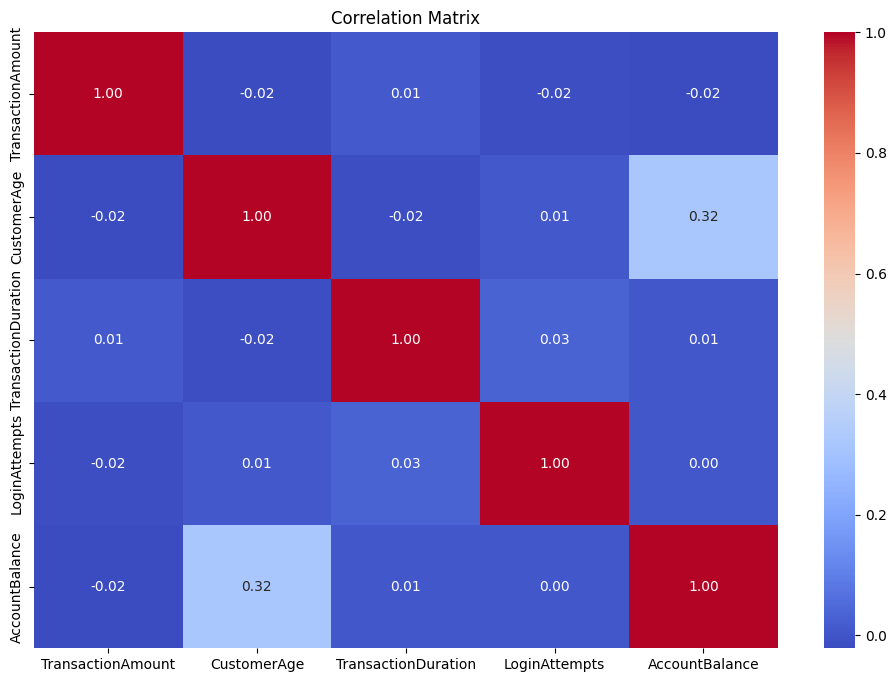

In [14]:
# Correlation Matrix
plt.figure(figsize=(12, 8))
correlation_matrix = df[numerical].corr()
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
)

plt.title('Correlation Matrix')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kamu menggunakan data tidak terstruktur.

In [15]:
# Dataset Copy
df_clean = df.copy()

In [16]:
# Drop Columns which not Useful for Modeling
drop_cols = ['TransactionID', 'AccountID', 'DeviceID', 'IP Address', 'MerchantID']
df_clean.drop(columns=drop_cols, inplace=True)
df_clean.shape

(50000, 10)

In [17]:
# Feature Engineering for TransactionDate Column
df_clean['TransactionDate'] = pd.to_datetime(df_clean['TransactionDate'], format='mixed', dayfirst=False)

df_clean['TransactionMonth'] = df_clean['TransactionDate'].dt.month
df_clean['TransactionDayOfWeek'] = df_clean['TransactionDate'].dt.dayofweek
df_clean['TransactionYear'] = df_clean['TransactionDate'].dt.year

df_clean.drop(columns='TransactionDate', inplace=True)
df_clean.shape

(50000, 12)

In [18]:
# Categorical Data Encoding
df_clean['TransactionType'] = df_clean['TransactionType'].map({'Debit': 0, 'Credit': 1})

le = LabelEncoder()
categorical_cols = ['Channel', 'CustomerOccupation', 'Location']
for col in categorical_cols:
    df_clean[col] = le.fit_transform(df_clean[col])

df_clean.head()

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionMonth,TransactionDayOfWeek,TransactionYear
0,14.09,0,36,0,70,0,81,1,5112.21,4,1,2023
1,376.24,0,15,0,68,0,141,1,13758.91,6,1,2023
2,126.29,0,23,2,19,3,56,1,1122.35,7,0,2023
3,184.50,0,33,2,26,3,25,1,8569.06,5,4,2023
4,13.45,1,1,2,26,3,198,1,7429.40,10,0,2023


In [19]:
# Login Attempts Binning
df_clean['LoginAttempts_Bin'] = (df_clean['LoginAttempts'] > 1).astype(int)
df_clean['LoginAttempts_Bin'].value_counts()

,count
LoginAttempts_Bin,
0,47547
1,2453


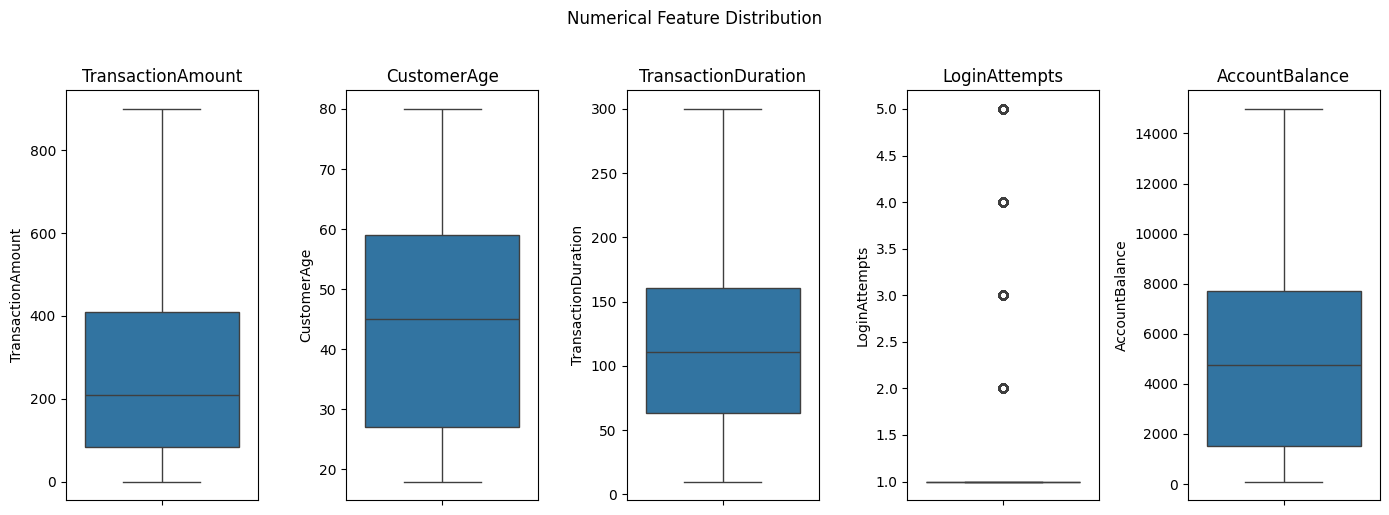

In [20]:
# Remove Outliers
def cap_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    df[col] = df[col].clip(lower=lower, upper=upper)

for col in ['TransactionAmount', 'AccountBalance', 'TransactionDuration']:
    cap_outliers_iqr(df_clean, col)

numerical_cols = ['TransactionAmount', 'CustomerAge', 'TransactionDuration', 'LoginAttempts', 'AccountBalance']
plt.figure(figsize=(14, 5))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(1, len(numerical_cols), i)
    sns.boxplot(y=df_clean[col])
    plt.title(f'{col}')
plt.suptitle('Numerical Feature Distribution', y=1.02)
plt.tight_layout()
plt.show()

In [21]:
# Feature Preparation for Unsupervised Learning
X = df_clean.copy()
print(f'Features Total: {X.shape[1]}')
print(f'Data Total: {X.shape[0]}')

Features Total: 13
Data Total: 50000


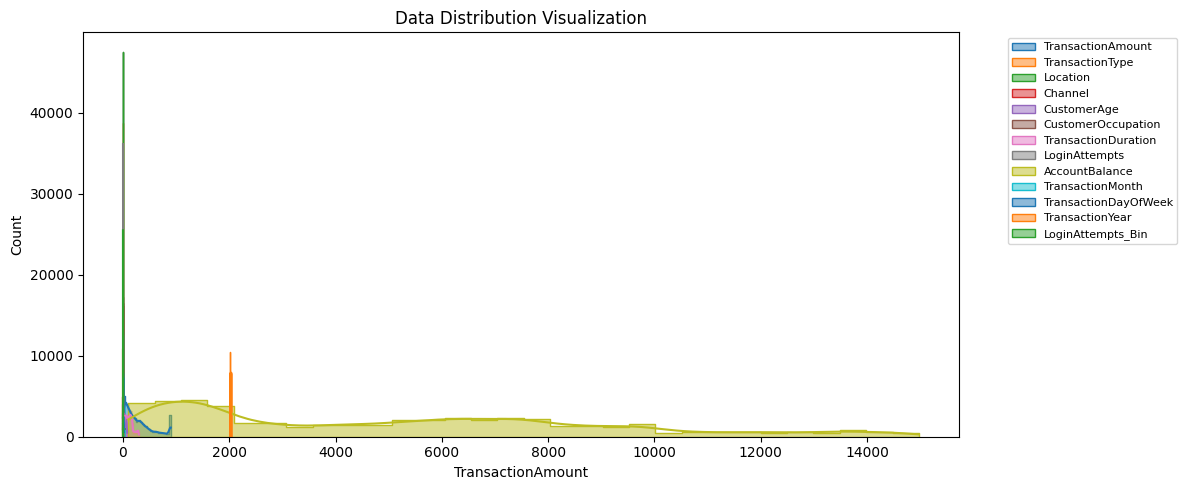

In [22]:
# Data Distribution Visualization
plt.figure(figsize=(12, 5))
for col in X.columns:
    sns.histplot(X[col], kde=True, label=col, bins=30, element='step')
plt.title('Data Distribution Visualization')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

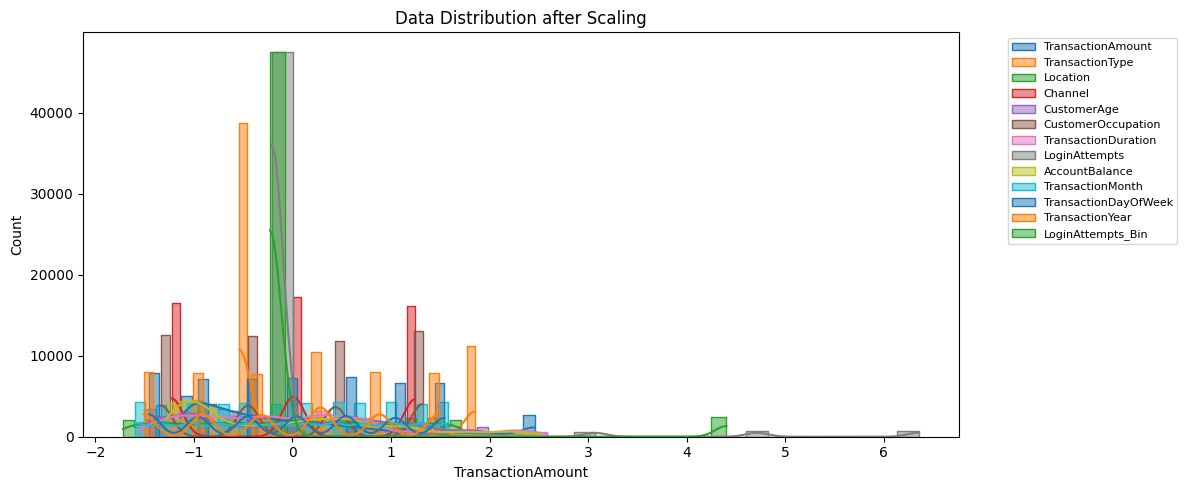

In [23]:
# Feature Standarization
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

plt.figure(figsize=(12, 5))
for col in X_scaled.columns:
    sns.histplot(X_scaled[col], kde=True, label=col, bins=30, element='step')
plt.title('Data Distribution after Scaling')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

In [24]:
# Convert to new CSV
df_clean.to_csv('bank_transactions_preprocessing.csv', index=False)